## Notebook to debug the latent space of the MNIST classifier and the MNIST autoencoder.

In [59]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os
import pathlib

In [60]:
## Hyperparameters
batch_size = 64
hidden_dim_1 = 64
hidden_dim_2 = 32
hidden_dim_3 = 16
latent_dim = 10
l_rate = 0.001
n_epochs = 50

In [61]:
## Dataset prep
transform = transforms.ToTensor()

data_dir = pathlib.Path("./data")
if data_dir.exists() and len(os.listdir("./data")) > 0:
    print("MNIST dataset already exists. Skipping download.")
else:
    print("Downloading MNIST dataset...")
    train_dataset = datasets.MNIST("./data", train=True, transform=transform, download=True)

train_load = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)

MNIST dataset already exists. Skipping download.


In [62]:
## Encoder and decoder 
encoder = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28*28,hidden_dim_1),
    nn.ReLU(),
    nn.Linear(hidden_dim_1,hidden_dim_2),
    nn.ReLU(),
    nn.Linear(hidden_dim_2, hidden_dim_3),
    nn.ReLU(),
    nn.Linear(hidden_dim_3, latent_dim),
    nn.Softmax()
)

decoder = nn.Sequential(
    nn.Linear(latent_dim, hidden_dim_3),
    nn.ReLU(),
    nn.Linear(hidden_dim_3, hidden_dim_2),
    nn.ReLU(),
    nn.Linear(hidden_dim_2, hidden_dim_1),
    nn.ReLU(),
    nn.Linear(hidden_dim_1, 28*28),
    nn.Sigmoid(),
    nn.Unflatten(1, (1, 28, 28))
    
)

In [74]:
# one-hot encoder function
def one_hot_encode(latent_vector: torch.Tensor) -> torch.Tensor:

    one_hot = torch.zeros_like(latent_vector)

    max_index = torch.argmax(latent_vector, dim=1)
    one_hot[torch.arange(latent_vector.size(0)), max_index] = 1.0

    return one_hot

In [69]:
## Class and init of the model

class Natural_Autoencoder(nn.Module):
    def __init__(self, encoder, decoder):
        super(Natural_Autoencoder, self).__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded, encoded

class Forced_Autoencoder(nn.Module):
    def __init__(self, encoder, decoder):
        super(Forced_Autoencoder, self).__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(one_hot_encode(encoded))
        return decoded, encoded

# Configuración del dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Model init
n_ae = Natural_Autoencoder(encoder, decoder).to(device)
f_ae = Forced_Autoencoder(encoder, decoder).to(device)

In [70]:
## Périda y optimizador
criterion = nn.MSELoss()
optimizer_n = optim.Adam(n_ae.parameters(), lr=l_rate)
optimizer_f = optim.Adam(f_ae.parameters(), lr=l_rate)

In [71]:
# Generación de imagenes
def plot_reconstructions(model_n, model_f, data_loader, epoch):
    model_n.eval()
    model_f.eval()
    with torch.no_grad():
        original_img, original_label = next(iter(data_loader))
        original_img = original_img.to(device)
        recons_img_n, latent_n = model_n(original_img)
        recons_img_f, latent_f = model_f(original_img)

    original_img = original_img.cpu()
    recons_img_n = recons_img_n.cpu()
    recons_img_f = recons_img_f.cpu()

    figs, axes = plt.subplots(3, 10, figsize=(12,5))
    for i in range(10):
        #imagenes originales
        axes[0,i].imshow(original_img[i].squeeze(), cmap="grey")
        axes[0,i].set_xlabel(f"Label: {original_label[i]}")
        axes[0,i].axis("off")
        if i == 4:
            axes[0,i].set_title(f"Epoch {epoch+1}")
        #imagenes reconstruidas
        axes[1,i].imshow(recons_img_n[i].squeeze(), cmap="grey")
        axes[1,i].set_xlabel(f"Label: {latent_n[i]}")
        axes[1,i].axis("off")

        axes[2,i].imshow(recons_img_f[i].squeeze(), cmap="grey")
        axes[2,i].set_xlabel(f"Label: {latent_f[i]}")
        axes[2,i].axis("off")

    plt.tight_layout()
    plt.show()


Epoch [1/50], Loss_n: 0.0674, Loss_f: 0.0674


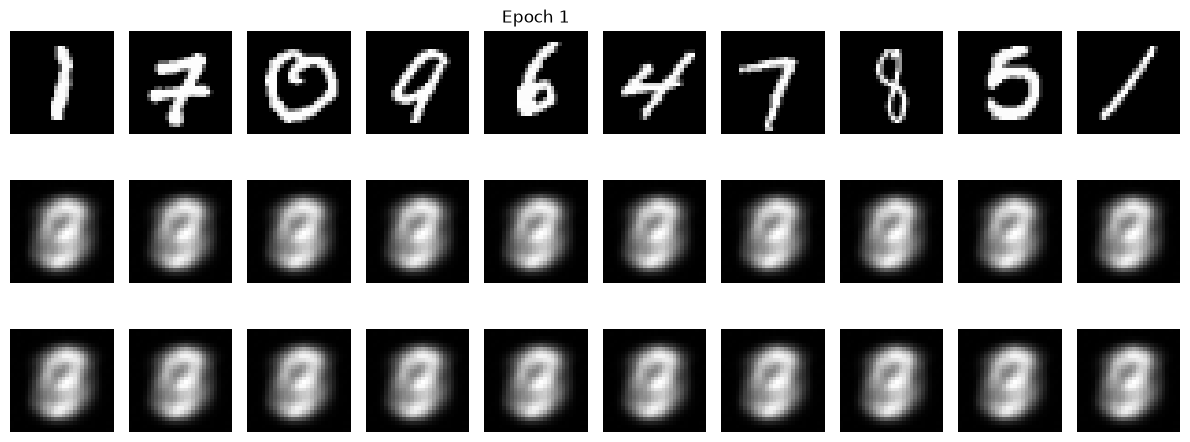

Epoch [2/50], Loss_n: 0.1347, Loss_f: 0.1347
Epoch [3/50], Loss_n: 0.2021, Loss_f: 0.2021
Epoch [4/50], Loss_n: 0.2694, Loss_f: 0.2694
Epoch [5/50], Loss_n: 0.3367, Loss_f: 0.3367
Epoch [6/50], Loss_n: 0.4041, Loss_f: 0.4041
Epoch [7/50], Loss_n: 0.4714, Loss_f: 0.4714
Epoch [8/50], Loss_n: 0.5387, Loss_f: 0.5387
Epoch [9/50], Loss_n: 0.6060, Loss_f: 0.6060
Epoch [10/50], Loss_n: 0.6733, Loss_f: 0.6733
Epoch [11/50], Loss_n: 0.7406, Loss_f: 0.7406


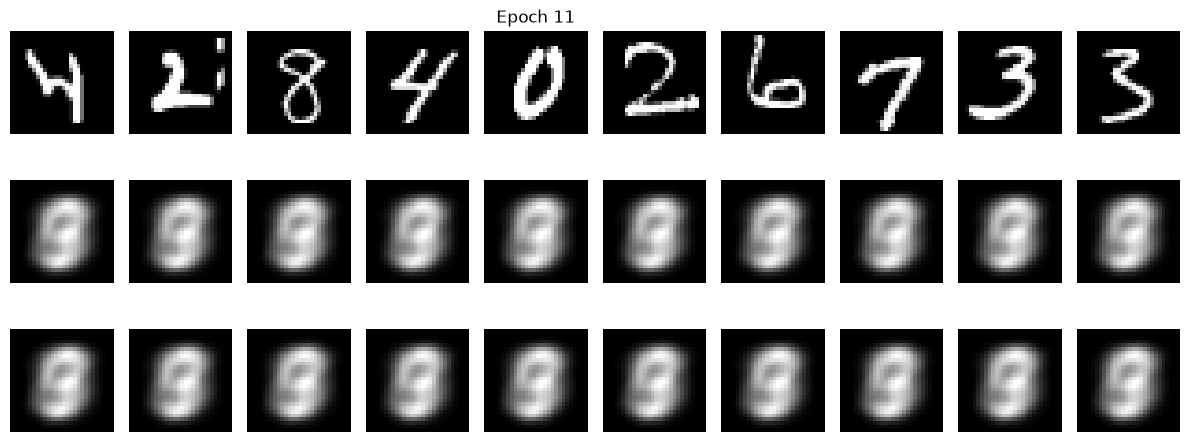

Epoch [12/50], Loss_n: 0.8079, Loss_f: 0.8079


In [ ]:
## Train

stored_loss_n = torch.zeros((n_epochs))
stored_loss_f = torch.zeros((n_epochs))

for epoch in range(n_epochs):
    total_loss_n = 0
    total_loss_f = 0
    for image, _ in train_load:
        image = image.to(device)
        reconstructed_img_n, _ = n_ae(image)
        reconstructed_img_f, _ = f_ae(image)
        loss_n = criterion(reconstructed_img_n, image)
        loss_f = criterion(reconstructed_img_f, image)

        optimizer_n.zero_grad()
        loss_n.backward()
        loss_f.backward()
        optimizer_f.step()

        total_loss_n += loss_n.item()
        total_loss_f += loss_f.item()
    
    stored_loss_n[epoch] = total_loss_n/len(train_load)
    stored_loss_f[epoch] = total_loss_f/len(train_load)

    print(f"Epoch [{epoch+1}/{n_epochs}], Loss_n: {stored_loss_n[epoch]:.4f}, Loss_f: {stored_loss_f[epoch]:.4f}")
    if epoch % 10 == 0:
        plot_reconstructions(n_ae, f_ae, train_load, epoch)

x = np.linspace(1,n_epochs,n_epochs)
plt.plot(x, stored_loss_n, label="Loss_n")
plt.plot(x, stored_loss_f, label="Loss_f")
plt.title("Loss vs epoch")
plt.xlabel("Epoch")
plt.ylabel("Avg loss")
plt.legend()

plt.show()